# Zentra Dataset Builder

For LightGBM + Prophet Modelling

In [46]:
# imports

%matplotlib inline
import warnings, re, os, time
from pathlib import Path

import requests
import pandas as pd
import numpy as np
import h3
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', font_scale=1.0)

BLUE, ORANGE, RED, GREEN, PURPLE = '#1a6bff', '#f59e0b', '#ef4444', '#22c55e', '#8b5cf6'
PERIOD_COLORS = {'AM': BLUE, 'MD': ORANGE, 'PM': GREEN}
PERIOD_ORDER = ['AM', 'MD', 'PM']

print(f'h3 version: {h3.__version__}')

h3 version: 4.5.0


In [47]:
# Directory layout 
# raw/       → downloaded files 
# processed/ → intermediate cleaned files
# master/    → final ML-ready CSVs
# plots/     → saved charts

DATA = Path('../data')
RAW = DATA / 'raw';       RAW.mkdir(parents=True, exist_ok=True)
PROC = DATA / 'processed'; PROC.mkdir(parents=True, exist_ok=True)
MASTER = DATA / 'master';    MASTER.mkdir(parents=True, exist_ok=True)
PLOTS = DATA / 'plots';     PLOTS.mkdir(parents=True, exist_ok=True)

print('Directories ready.')

Directories ready.


In [48]:
# Global config 

H3_RES = 8   # Resolution 8 hexagons are ~460 m across — good city-block level

# These are the three time windows DOT uses for their counts
PERIOD_WINDOWS = {
    'AM': range(7, 10),   # Morning rush: 7–9 AM
    'MD': range(11, 14),  # Midday:       11 AM – 1 PM
    'PM': range(16, 19),  # Evening rush: 4–6 PM
}

def hour_to_period(hour):
    """Map an hour (0-23) to AM / MD / PM, or None if outside windows."""
    for period, hrs in PERIOD_WINDOWS.items():
        if hour in hrs:
            return period
    return None

# Manhattan TLC zone IDs — we use these to filter taxi trips to Manhattan only
MANHATTAN_ZONES = {
    4, 12, 13, 24, 41, 42, 43, 45, 48, 50, 68, 74, 75, 79, 87, 88, 90, 100,
    103, 104, 105, 107, 113, 114, 116, 120, 125, 127, 128, 137, 140, 141, 142,
    143, 144, 148, 151, 152, 153, 158, 161, 162, 163, 164, 166, 170, 186, 194,
    202, 209, 211, 224, 229, 230, 231, 232, 233, 234, 236, 237, 238, 239, 243,
    244, 246, 249, 261, 262, 263,
}

# Month name - month number (DOT column names use short month names)
MONTH_MAP = {'May': 5, 'Sept': 9, 'Oct': 10, 'June': 6, 'Mar': 3}

# Socrata (NYC Open Data) base URL
SOCRATA_BASE = 'https://data.cityofnewyork.us/resource'


## Helpers Functions

Two functions we'll call after loading every dataset:
- **`dqr()`** — prints a quick summary box (rows, columns, nulls, date range)
- **`dqp()`** — returns a per-column stats table (dtype, nulls, min/max/mean/unique)

In [49]:
def dqr(name, df, date_col=None):
    """Data Quality Report — prints a summary banner for the dataframe."""
    n_null = int(df.isnull().sum().sum())
    null_pct = n_null / df.size * 100 if df.size else 0
    print(f'DATA QUALITY REPORT — {name:<38}')
    print(f'Rows: {df.shape[0]:>10,}')
    print(f'Columns: {df.shape[1]:>10,}')
    null_str = f'{n_null:,} ({null_pct:.2f}%)'
    print(f'Null cells: {null_str:<50}')
    if date_col and date_col in df.columns and len(df):
        lo = str(df[date_col].min())[:10]
        hi = str(df[date_col].max())[:10]
        print(f'Date range: {lo}  →  {hi}')


def dqp(df):
    """Data Quality Profile — per-column stats table."""
    rows = []
    for col in df.columns:
        s = df[col]
        n_null = s.isna().sum()
        row = {
            'column': col,
            'dtype': str(s.dtype),
            'null_count': int(n_null),
            'null_pct': round(n_null / len(df) * 100, 2) if len(df) else 0,
            'unique': int(s.nunique()),
        }
        if pd.api.types.is_numeric_dtype(s) and n_null < len(df):
            row.update({
                'min': round(float(s.min()),    3),
                'mean': round(float(s.mean()),   3),
                'median': round(float(s.median()), 3),
                'max': round(float(s.max()),    3),
            })
        rows.append(row)
    return pd.DataFrame(rows).set_index('column')


def norm_score(x):
    """Normalise a series to 0-100 using z-score clipped at +3 0r -3."""
    z = (x - x.mean()) / (x.std() + 1e-6)
    return ((z.clip(-3, 3) + 3) / 6 * 100).round(2)


def save_dqp(df, name):
    """Save a DQP table to CSV and print where it went."""
    path = PROC / f'dqp_{name}.csv'
    dqp(df).to_csv(path)
    print(f'  DQP saved - {path}')


print('DQR / DQP helpers ready.')

DQR / DQP helpers ready.


## 1 · Pedestrian Location Geocoding

The DOT dataset has 36 survey corridors in Manhattan (Broadway, 5th Ave, 34th St crosstown, etc.).

**Real coordinates, no hardcoding:** the source CSV includes a `the_geom` column
(WKT `POINT (lon lat)`) for every corridor — so instead of a hand-typed lookup table,
we parse the real coordinates straight out of the file and assign each one to an H3 cell.
This also guarantees `location_id` here exactly matches `Loc` in the pedestrian counts
section below, since they come from the same source rows.


In [50]:
# Load the pedestrian CSV once, extract Manhattan corridor coords ─
# We load the raw DOT CSV here (and reuse it in Section 2) rather than
# hand-typing a lookup table — that guarantees location_id always matches
# the real 'Loc' values in the source data, instead of drifting out of sync.

PED_CSV_PATH = RAW / 'Bi-Annual_Pedestrian_Counts_20260614.csv'  # update if your filename differs

ped_raw = pd.read_csv(PED_CSV_PATH)

# Fix a common typo in column names (pM → PM)
ped_raw.columns = [c.replace('_pM', '_PM') for c in ped_raw.columns]

ped_man_raw = ped_raw[ped_raw['Borough'] == 'Manhattan'].copy()


def _parse_wkt_point(wkt):
    """Parse 'POINT (lon lat)' → (lat, lon). Returns (None, None) if unparseable."""
    if pd.isna(wkt):
        return None, None
    m = re.match(r'POINT\s*\(\s*(-?\d+\.?\d*)\s+(-?\d+\.?\d*)\s*\)', str(wkt))
    if not m:
        return None, None
    lon, lat = float(m.group(1)), float(m.group(2))
    return lat, lon


loc_rows = []
for _, row in ped_man_raw.iterrows():
    lat, lon = _parse_wkt_point(row.get('the_geom'))
    if lat is None:
        continue  # skip corridors with no parseable geometry
    desc = f"{row['Street_Nam']} ({row['From_Stree']} to {row['To_Street']})"
    loc_rows.append({
        'location_id': row['Loc'],
        'lat': lat,
        'lon': lon,
        'description': desc,
    })

loc_df = pd.DataFrame(loc_rows)
loc_df['h3_cell'] = loc_df.apply(
    lambda r: h3.latlng_to_cell(r['lat'], r['lon'], H3_RES), axis=1
)

# Save it
loc_df.to_csv(PROC / 'location_geocoded.csv', index=False)

n_skipped = len(ped_man_raw) - len(loc_df)
print(f'Geocoded {len(loc_df)} Manhattan survey locations from real the_geom data')
if n_skipped:
    print(f'  ({n_skipped} corridors skipped — no parseable the_geom)')
print(f'Unique H3 cells at resolution {H3_RES}: {loc_df["h3_cell"].nunique()}')
print(f'(Some corridors share a cell — that is normal at 460 m resolution)')
display(loc_df.head(8))


Geocoded 36 Manhattan survey locations from real the_geom data
Unique H3 cells at resolution 8: 20
(Some corridors share a cell — that is normal at 460 m resolution)


,location_id,lat,lon,description,h3_cell
0,35,40.705,-74.012,Broad Street (Beaver Street to South William S...,882a107281fffff
1,36,40.706,-74.013,Broadway (Morris Street to Exchange Place),882a107281fffff
2,37,40.772,-73.982,Broadway (West 63rd Street to West 64th Street),882a1008b3fffff
3,38,40.716,-74.010,Chambers Street (West Broadway to Greenwich St...,882a1072c7fffff
4,39,40.780,-73.977,Columbus Avenue (West 75th Street to West 76th...,882a1008bbfffff
5,40,40.719,-73.989,Delancey Street (Orchard Street to Ludlow Street),882a1072cbfffff
6,41,40.736,-73.993,East 14th Street (Fifth Avenue to University P...,882a100d27fffff
7,42,40.752,-73.977,East 42 Street (Park Avenue to Lexington Avenue),882a100d63fffff


## 2 · Pedestrian Counts — All Historical Survey Dates (2007–2025)

The NYC DOT runs a bi-annual pedestrian count along major Manhattan corridors.
The CSV has one row per corridor, with columns like `May07_AM`, `Sept10_PM`, etc.
Need to reshape it from **wide** (one column per survey × period) to **long**
(one row per corridor × survey date × period).

**Need to download the CSV first:**
1. Go to https://data.cityofnewyork.us/Transportation/Bi-Annual-Pedestrian-Counts/2de4-3jh6
2. Click "Export → CSV"
3. Save it as `Bi-Annual_Pedestrian_Counts.csv` in the same folder as this notebook

Or update `PED_CSV_PATH` below to point to wherever I have saved it.

In [51]:
# Identify count columns (CSV already loaded)
# ped_raw / ped_man_raw were already loaded and Manhattan-filtered in
# Section 1 so location_id stays in sync with the geocoded loc_df.
# We just need the count-column names here.

# Identify the count columns — they look like "May07_AM", "Sept19_PM", "Oct22_MD"
meta_cols  = ['Loc', 'Borough', 'Street_Nam', 'From_Stree', 'To_Street']
count_cols = [c for c in ped_raw.columns if re.match(r'[A-Za-z]+\d{2}_(AM|PM|MD)', c)]

print(f'Raw shape: {ped_raw.shape}')
print(f'Boroughs:  {ped_raw["Borough"].value_counts().to_dict()}')
print(f'Found {len(count_cols)} count columns (survey × period combos)')
print(f'Sample column names: {count_cols[:6]}')


Raw shape: (114, 116)
Boroughs:  {'Manhattan': 36, 'Brooklyn': 26, 'Queens': 25, 'Harlem River Bridges': 9, 'Bronx': 8, 'Staten Isla': 5, 'East River Bridges': 5}
Found 108 count columns (survey × period combos)
Sample column names: ['May07_AM', 'May07_PM', 'May07_MD', 'Sept07_AM', 'Sept07_PM', 'Sept07_MD']


In [52]:
# ── 2.2  Reshape wide → long, Manhattan only ─────────────────────────────
#
# For each corridor row, we loop through every count column, parse the
# season + year + period out of the column name, and emit one long row.

ped_man = ped_man_raw.copy()  # already filtered to Manhattan in Section 1.1
print(f'Manhattan corridors: {len(ped_man)}')

long_rows = []
for _, row in ped_man.iterrows():
    for col in count_cols:
        m = re.match(r'([A-Za-z]+)(\d{2})_(AM|PM|MD)', col)
        if not m:
            continue
        season, yy, period = m.groups()
        val = row[col]
        if pd.isna(val):
            continue
        # Clean up numbers that might be stored as strings with commas
        val = float(str(val).replace(',', ''))
        if val < 0:
            continue  # Skip negative counts (data errors)
        year  = 2000 + int(yy)
        month = MONTH_MAP.get(season)
        if month is None:
            continue  # Skip seasons we don't recognise
        # DOT surveys happen on the 15th of the month
        survey_date = f'{year:04d}-{month:02d}-15'
        long_rows.append({
            'location_id': row['Loc'],
            'street':      row['Street_Nam'],
            'from_street': row['From_Stree'],
            'to_street':   row['To_Street'],
            'borough':     row['Borough'],
            'survey_date': survey_date,
            'year':        year,
            'month':       month,
            'season':      season,
            'period':      period,
            'pedestrians': val,
        })

ped_long = pd.DataFrame(long_rows)
ped_long['survey_date'] = pd.to_datetime(ped_long['survey_date'])
ped_long = ped_long.sort_values(['location_id', 'survey_date', 'period']).reset_index(drop=True)

ped_long.to_csv(PROC / 'pedestrian_long.csv', index=False)

print(f'Long format shape: {ped_long.shape}')
print(f'Survey dates found: {sorted(ped_long["survey_date"].dt.strftime("%Y-%m").unique())}')
print(f'Unique locations: {ped_long["location_id"].nunique()}')

Manhattan corridors: 36
Long format shape: (3826, 11)
Survey dates found: ['2007-05', '2007-09', '2008-05', '2008-09', '2009-05', '2009-09', '2010-05', '2010-09', '2011-05', '2011-09', '2012-05', '2012-09', '2013-05', '2013-09', '2014-05', '2014-09', '2015-05', '2015-09', '2016-05', '2016-09', '2017-05', '2017-09', '2018-05', '2018-09', '2019-05', '2020-10', '2021-05', '2021-10', '2022-05', '2022-10', '2023-05', '2023-10', '2024-06', '2024-10', '2025-05', '2025-10']
Unique locations: 36


In [53]:
#  Attach H3 cells and compute a normalised score ─────────────────

ped_long = ped_long.merge(
    loc_df[['location_id', 'lat', 'lon', 'h3_cell', 'description']],
    on='location_id',
    how='left'
)

n_matched   = ped_long['h3_cell'].notna().sum()
n_unmatched = ped_long['h3_cell'].isna().sum()
print(f'Rows with H3 cell:    {n_matched:,} ({n_matched/len(ped_long)*100:.1f}%)')
print(f'Rows without H3 cell: {n_unmatched:,}')

if n_unmatched > 0:
    missing = ped_long.loc[ped_long['h3_cell'].isna(), 'location_id'].unique()
    print(f'  Missing location IDs: {missing} — add them to LOCATION_COORDS in Section 1')

# Normalised pedestrian score (0–100) relative to all locations on the same date × period
# Useful as a relative density measure for modelling
ped_long['ped_score']   = ped_long.groupby(['survey_date', 'period'])['pedestrians'].transform(norm_score)
ped_long['day_of_week'] = ped_long['survey_date'].dt.dayofweek

ped_long.to_csv(PROC / 'pedestrian_long_h3.csv', index=False)
print(f'Saved → {PROC / "pedestrian_long_h3.csv"}')

dqr('Pedestrian counts — all survey dates', ped_long, date_col='survey_date')

Rows with H3 cell:    3,826 (100.0%)
Rows without H3 cell: 0
Saved → ..\data\processed\pedestrian_long_h3.csv
DATA QUALITY REPORT — Pedestrian counts — all survey dates  
Rows:      3,826
Columns:         17
Null cells: 0 (0.00%)                                         
Date range: 2007-05-15  →  2025-10-15


In [54]:
# DQP on pedestrian data 

display(dqp(ped_long))
save_dqp(ped_long, 'pedestrian')

,dtype,null_count,null_pct,unique,min,mean,median,max
column,,,,,,,,
location_id,int64,0,0.000,36,35.000,52.443,52.000,70.000
street,object,0,0.000,28,NaN,NaN,NaN,NaN
from_street,object,0,0.000,24,NaN,NaN,NaN,NaN
to_street,object,0,0.000,24,NaN,NaN,NaN,NaN
borough,object,0,0.000,1,NaN,NaN,NaN,NaN
survey_date,datetime64[ns],0,0.000,36,NaN,NaN,NaN,NaN
year,int64,0,0.000,19,2007.000,2015.746,2015.000,2025.000
month,int64,0,0.000,4,5.000,7.212,9.000,10.000
season,object,0,0.000,4,NaN,NaN,NaN,NaN


  DQP saved - ..\data\processed\dqp_pedestrian.csv


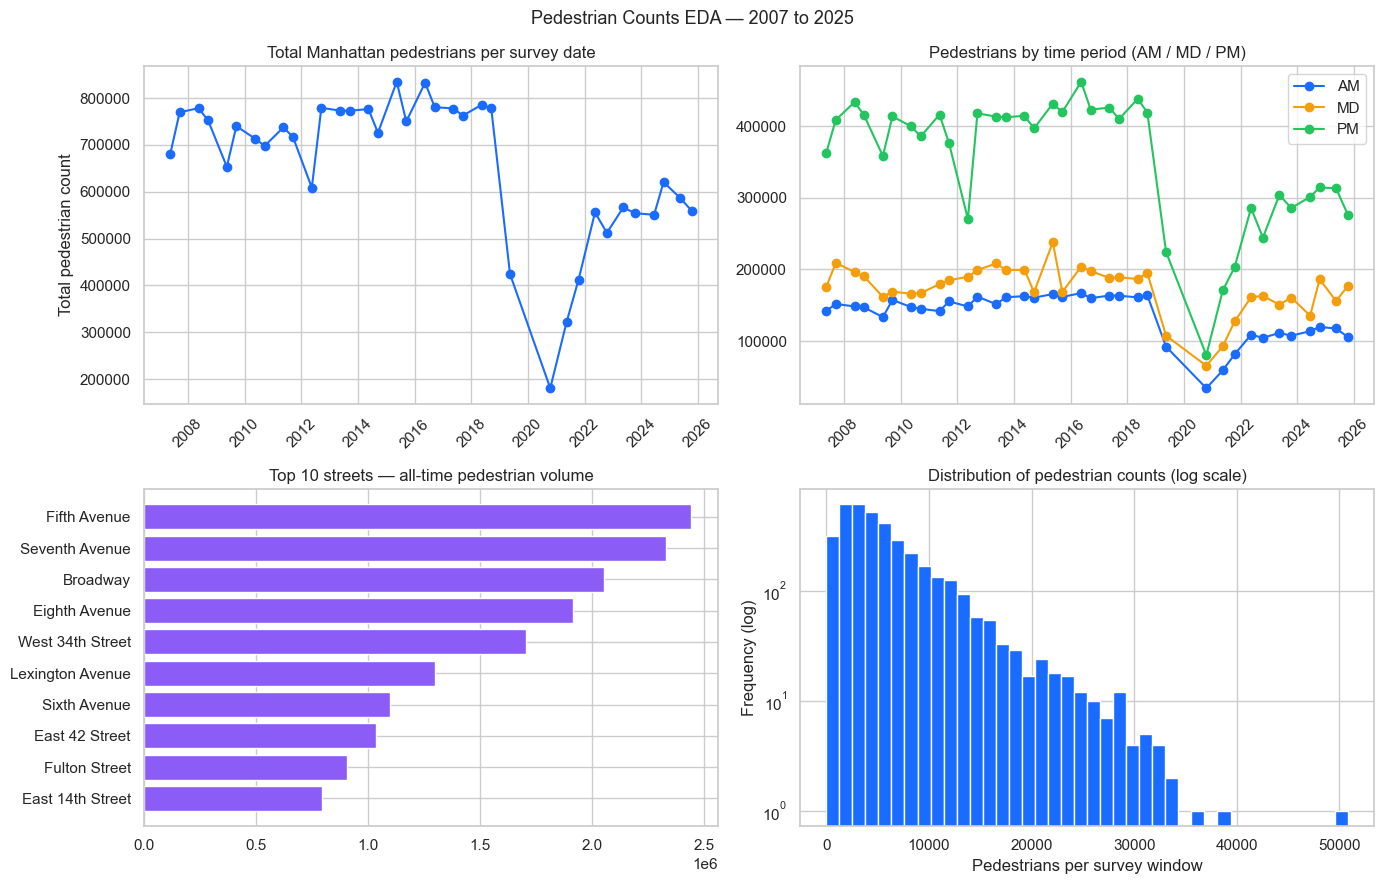

Key facts:
  36 survey dates, 36 locations, 3,826 rows total
  Count range: 0 to 50,827
  Most-counted street: Fifth Avenue (2,440,867 all-time)


In [55]:
# ── 2.5  EDA — what do the pedestrian counts look like? ─────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Total Manhattan pedestrians per survey date (all periods summed)
date_totals = ped_long.groupby('survey_date')['pedestrians'].sum().reset_index()
axes[0, 0].plot(date_totals['survey_date'], date_totals['pedestrians'], 'o-', color=BLUE)
axes[0, 0].set_title('Total Manhattan pedestrians per survey date')
axes[0, 0].set_ylabel('Total pedestrian count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Breakdown by period over time
period_year = ped_long.groupby(['survey_date', 'period'])['pedestrians'].sum().reset_index()
for p in PERIOD_ORDER:
    sub = period_year[period_year['period'] == p]
    axes[0, 1].plot(sub['survey_date'], sub['pedestrians'], 'o-',
                    label=p, color=PERIOD_COLORS[p])
axes[0, 1].set_title('Pedestrians by time period (AM / MD / PM)')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# Top 10 streets by all-time total volume
top_streets = ped_long.groupby('street')['pedestrians'].sum().nlargest(10)
axes[1, 0].barh(top_streets.index, top_streets.values, color=PURPLE)
axes[1, 0].invert_yaxis()
axes[1, 0].set_title('Top 10 streets — all-time pedestrian volume')

# Distribution of counts (log scale because it is very skewed)
axes[1, 1].hist(ped_long['pedestrians'], bins=40, color=BLUE, edgecolor='white', log=True)
axes[1, 1].set_title('Distribution of pedestrian counts (log scale)')
axes[1, 1].set_xlabel('Pedestrians per survey window')
axes[1, 1].set_ylabel('Frequency (log)')

plt.suptitle('Pedestrian Counts EDA — 2007 to 2025', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS / 'eda_pedestrian_trends.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Key facts:')
print(f'  {ped_long["survey_date"].nunique()} survey dates, {ped_long["location_id"].nunique()} locations, {len(ped_long):,} rows total')
print(f'  Count range: {ped_long["pedestrians"].min():.0f} to {ped_long["pedestrians"].max():,.0f}')
print(f'  Most-counted street: {top_streets.idxmax()} ({top_streets.max():,.0f} all-time)')

## 3 · TLC Trips — Yellow Taxi + Uber/Lyft (HVFHV)

This is the big one. We pull two datasets from NYC Open Data:

- **Yellow Taxi** (`m6nq-qud6`) — traditional yellow cabs
- **HVFHV** (`23pu-xa2h`) — High Volume FHV = Uber, Lyft, Via

Both use `PULocationID` (the TLC zone number), so first build a lookup table
that maps each zone ID to an H3 hexagon using zone centroid coordinates.
Then we aggregate trips to `(h3_cell, period)` for each survey month.

### Why both Yellow and HVFHV?
By ~2023 HVFHV trips outnumber Yellow trips in Manhattan 3:1.
Using only yellow taxis would badly under-count actual vehicle-based demand.

In [56]:
# TLC zone → H3 centroid lookup 
# These are the approximate centroids of each Manhattan TLC zone.
# Source: TLC zone shapefile centroids (https://www.nyc.gov/site/tlc)

TLC_ZONE_CENTROIDS = {
    4:   (40.7282, -74.0027, 'Alphabet City / East Village'),
    12:  (40.7614, -73.9914, 'Columbus Circle / Hell\'s Kitchen'),
    13:  (40.7529, -73.9895, 'Hudson Yards'),
    24:  (40.7135, -74.0083, 'Battery Park'),
    41:  (40.7517, -73.9757, 'Central Midtown'),
    42:  (40.7648, -73.9808, 'Central Park South'),
    43:  (40.7806, -73.9789, 'Central Park West'),
    45:  (40.7127, -74.0059, 'City Hall / Civic Center'),
    48:  (40.7412, -74.0003, 'Chelsea'),
    50:  (40.7210, -74.0045, 'Chinatown'),
    68:  (40.8071, -73.9642, 'East Harlem'),
    74:  (40.7248, -73.9956, 'East Village'),
    75:  (40.7189, -73.9893, 'Lower East Side'),
    79:  (40.7464, -73.9786, 'East Midtown'),
    87:  (40.7692, -73.9838, 'Upper West Side'),
    88:  (40.7801, -73.9720, 'Upper West Side North'),
    90:  (40.7412, -74.0082, 'Meatpacking District'),
    100: (40.7546, -73.9925, 'Garment District'),
    103: (40.7362, -74.0012, 'Greenwich Village'),
    104: (40.7390, -74.0083, 'West Village'),
    105: (40.7328, -74.0033, 'Greenwich Village South'),
    107: (40.8011, -73.9537, 'Harlem'),
    113: (40.7628, -73.9661, 'Lenox Hill'),
    114: (40.7756, -73.9588, 'Lincoln Square'),
    116: (40.7490, -73.9880, 'Midtown Center'),
    120: (40.7565, -73.9936, 'Midtown North'),
    125: (40.7445, -73.9892, 'Midtown South'),
    127: (40.7485, -73.9742, 'Murray Hill'),
    128: (40.7424, -73.9793, 'Kips Bay / NoMad'),
    137: (40.7116, -74.0121, 'Financial District North'),
    140: (40.7076, -74.0128, 'Financial District South'),
    141: (40.7047, -74.0131, 'Financial District South'),
    142: (40.7566, -73.9867, 'Lincoln Square'),
    143: (40.7620, -73.9795, 'Upper East Side South'),
    144: (40.7698, -73.9627, 'Upper East Side North'),
    148: (40.7413, -73.9889, 'Flatiron / Madison Sq'),
    151: (40.8200, -73.9503, 'Inwood'),
    152: (40.8280, -73.9418, 'Marble Hill'),
    153: (40.7898, -73.9756, 'Manhattan Valley'),
    158: (40.7533, -73.9784, 'Midtown East'),
    161: (40.7585, -73.9921, 'Midtown West'),
    162: (40.7579, -73.9965, 'Hell\'s Kitchen South'),
    163: (40.7686, -73.9907, 'Lincoln Center'),
    164: (40.7706, -73.9796, 'Upper West Side Central'),
    166: (40.7560, -73.9836, 'Midtown East North'),
    170: (40.7312, -74.0048, 'Hudson Square'),
    186: (40.7143, -73.9966, 'Little Italy / NoLiTa'),
    194: (40.7459, -74.0073, 'Hudson Yards South'),
    202: (40.7531, -73.9822, '5th Ave / Bryant Park'),
    209: (40.7213, -74.0109, 'Tribeca / Civic Center'),
    211: (40.7095, -74.0095, 'World Trade Center'),
    224: (40.7281, -74.0036, 'SoHo'),
    229: (40.7196, -73.9999, 'Lower East Side North'),
    230: (40.7141, -73.9948, 'Two Bridges / Seaport'),
    231: (40.7044, -74.0117, 'Battery Park City'),
    232: (40.7068, -74.0164, 'Greenwich St South'),
    233: (40.7150, -74.0082, 'Washington St'),
    234: (40.7223, -74.0069, 'Tribeca North'),
    236: (40.8100, -73.9557, 'Central Harlem North'),
    237: (40.8060, -73.9530, 'Central Harlem South'),
    238: (40.8142, -73.9467, 'East Harlem North'),
    239: (40.7970, -73.9454, 'Yorkville East'),
    243: (40.7786, -73.9528, 'Yorkville West'),
    244: (40.7842, -73.9532, 'Upper East Side Far North'),
    246: (40.7893, -73.9672, 'Upper West Side Far North'),
    249: (40.7812, -73.9792, 'Riverside Side South'),
    261: (40.7561, -73.9949, 'Theater District / Times Square'),
    262: (40.7530, -73.9780, 'Turtle Bay / United Nations'),
    263: (40.7480, -73.9720, 'Kips Bay East'),
}

# Build a zone dataframe with H3 cells
zone_df = pd.DataFrame([
    {'zone_id': zid, 'lat': lat, 'lon': lon, 'neighborhood': name}
    for zid, (lat, lon, name) in TLC_ZONE_CENTROIDS.items()
])
zone_df['h3_cell'] = zone_df.apply(
    lambda r: h3.latlng_to_cell(r['lat'], r['lon'], H3_RES), axis=1
)
zone_df.to_csv(PROC / 'tlc_zone_h3_lookup.csv', index=False)

print(f'TLC zone lookup: {len(zone_df)} Manhattan zones → {zone_df["h3_cell"].nunique()} unique H3 cells')
display(zone_df.head(5))

TLC zone lookup: 69 Manhattan zones → 38 unique H3 cells


,zone_id,lat,lon,neighborhood,h3_cell
0,4,40.728,-74.003,Alphabet City / East Village,882a1072cdfffff
1,12,40.761,-73.991,Columbus Circle / Hell's Kitchen,882a10725bfffff
2,13,40.753,-73.990,Hudson Yards,882a100d2dfffff
3,24,40.714,-74.008,Battery Park,882a107289fffff
4,41,40.752,-73.976,Central Midtown,882a100d63fffff


### 3.1 · Download functions — Yellow Taxi and HVFHV

Define two separate fetch functions (one per vehicle type) and then a combiner.
Both hit the NYC Open Data Socrata API, which lets filter by month, zone, and hour
without downloading the full dataset (which is tens of millions of rows per month).

**Caching:** once a month is downloaded it is saved as CSV. If you re-run the notebook,
it just reads from cache — no re-downloading.

In [57]:
# ── 3.2a  Fetch Yellow Taxi for one survey month (Parquet → CSV) ─────────
#
# Yellow taxi Parquet files: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_YYYY-MM.parquet
#
# IMPORTANT — the column schema has changed multiple times over the years:
#   2009 – mid-2010 :  Trip_Pickup_DateTime, Start_Lon, Start_Lat   (lat/lon, no zone ID)
#   mid-2010 – 2016  :  pickup_datetime,      pickup_longitude/latitude (lat/lon, no zone ID)
#   mid-2016 onward  :  tpep_pickup_datetime, PULocationID           (zone ID, no lat/lon)
#
# Our pipeline keys everything off PULocationID (via the TLC zone→H3 centroid
# lookup in section 3.1), so months before the zone-ID era (~July 2016) can't
# be matched to a TLC zone and are skipped here. This mirrors a real limitation
# of the open TLC data, not a bug — there's no zone ID to join on before then.

import urllib.request

TLC_YELLOW_URL = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month:02d}.parquet'
TLC_HVFHV_URL  = 'https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_{year}-{month:02d}.parquet'

AM_MD_PM_HOURS = set(range(7, 10)) | set(range(11, 14)) | set(range(16, 19))

# First year × month where Yellow Parquet reliably has PULocationID
YELLOW_ZONE_ID_START = (2016, 7)


def _download_parquet(url, dest_path):
    """Download a Parquet file from url to dest_path. Returns True on success."""
    try:
        print(f'    Downloading {url.split("/")[-1]} ...', end=' ', flush=True)
        urllib.request.urlretrieve(url, dest_path)
        size_mb = dest_path.stat().st_size / 1e6
        print(f'{size_mb:.1f} MB')
        return True
    except Exception as e:
        print(f'FAILED ({e})')
        if dest_path.exists():
            dest_path.unlink()  # remove partial download
        return False


def _read_parquet_schema_cols(parquet_path):
    """Return the set of column names in a Parquet file without loading data."""
    import pyarrow.parquet as pq
    return set(pq.ParquetFile(parquet_path).schema_arrow.names)


def fetch_yellow_month(year, month):
    """
    Download Yellow taxi Parquet for year-month from the TLC CDN,
    filter to Manhattan zones + AM/MD/PM hours, convert to CSV, and cache.
    Returns a tidy DataFrame with standardised columns, or None on failure
    or if the month predates the PULocationID zone-ID era.
    """
    if year < 2009:
        return None  # TLC open data only goes back to 2009
    if (year, month) < YELLOW_ZONE_ID_START:
        # Pre-zone-ID era — file uses lat/lon, not PULocationID. Our zone-based
        # H3 join can't use this month, so skip rather than mis-map it.
        print(f'    (pre-zone-ID schema for {year}-{month:02d} — skipping)', end='  ')
        return None

    # CSV cache — if already processed, skip download entirely
    cache = RAW / f'yellow_{year}_{month:02d}.csv'
    if cache.exists():
        df = pd.read_csv(cache)
        df['pickup_dt'] = pd.to_datetime(df['pickup_dt'])
        return df

    # Download Parquet
    parquet_path = RAW / f'yellow_{year}_{month:02d}.parquet'
    if not parquet_path.exists():
        url = TLC_YELLOW_URL.format(year=year, month=month)
        if not _download_parquet(url, parquet_path):
            return None

    # Check schema before reading — older files between the boundary months
    # sometimes use slightly different capitalisation; handle defensively.
    try:
        available = _read_parquet_schema_cols(parquet_path)
    except Exception as e:
        print(f'    Schema read error (yellow {year}-{month:02d}): {e}')
        parquet_path.unlink(missing_ok=True)
        return None

    pickup_col = next((c for c in ['tpep_pickup_datetime', 'pickup_datetime'] if c in available), None)
    zone_col   = next((c for c in ['PULocationID', 'pulocationid'] if c in available), None)

    if pickup_col is None or zone_col is None:
        print(f'    No zone-ID pickup schema in {year}-{month:02d} (cols: {sorted(available)[:6]}...) — skipping')
        parquet_path.unlink(missing_ok=True)
        return None

    fare_col = next((c for c in ['fare_amount', 'Fare_Amt'] if c in available), None)
    dist_col = next((c for c in ['trip_distance', 'Trip_Distance'] if c in available), None)
    read_cols = [c for c in [pickup_col, zone_col, fare_col, dist_col] if c]

    try:
        df = pd.read_parquet(parquet_path, columns=read_cols, engine='pyarrow')
    except Exception as e:
        print(f'    Parquet read error (yellow {year}-{month:02d}): {e}')
        parquet_path.unlink(missing_ok=True)
        return None

    # Rename to our standard schema
    rename_map = {pickup_col: 'pickup_dt', zone_col: 'PULocationID'}
    if fare_col: rename_map[fare_col] = 'fare_amount'
    if dist_col: rename_map[dist_col] = 'trip_distance'
    df = df.rename(columns=rename_map)

    if 'fare_amount' not in df.columns:   df['fare_amount']   = np.nan
    if 'trip_distance' not in df.columns: df['trip_distance'] = np.nan

    df['pickup_dt']     = pd.to_datetime(df['pickup_dt'], errors='coerce')
    df['PULocationID']  = pd.to_numeric(df['PULocationID'], errors='coerce')
    df['fare_amount']   = pd.to_numeric(df['fare_amount'],  errors='coerce')
    df['trip_distance'] = pd.to_numeric(df['trip_distance'], errors='coerce')
    df['vehicle_type']  = 'yellow'

    df = df.dropna(subset=['pickup_dt', 'PULocationID'])
    df = df[df['PULocationID'].isin(MANHATTAN_ZONES)]
    df = df[df['pickup_dt'].dt.hour.isin(AM_MD_PM_HOURS)]

    # Save as CSV cache and remove the Parquet to save disk space
    df.to_csv(cache, index=False)
    parquet_path.unlink(missing_ok=True)

    return df


print('Yellow taxi Parquet→CSV fetch function defined (schema-aware).')


Yellow taxi Parquet→CSV fetch function defined (schema-aware).


In [58]:
# ── 3.2b  Fetch HVFHV (Uber/Lyft) for one survey month (Parquet → CSV) ──
#
# HVFHV trip records (Uber = HV0003, Lyft = HV0005) are published as Parquet
# on the TLC CDN alongside the yellow-taxi files:
#   https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_YYYY-MM.parquet
#
# HVFHV data starts from February 2019.
# Column mapping (different from yellow):
#   pickup_datetime      → pickup_dt
#   base_passenger_fare  → fare_amount
#   trip_miles           → trip_distance
#   hvfhs_license_num    → used to distinguish Uber (HV0003) vs Lyft (HV0005)

def fetch_hvfhv_month(year, month):
    """
    Download HVFHV Parquet for year-month from the TLC CDN,
    filter to Manhattan zones + AM/MD/PM hours, convert to CSV, and cache.
    Returns a tidy DataFrame with standardised columns, or None on failure.
    """
    if year < 2019 or (year == 2019 and month < 2):
        return None  # HVFHV data starts Feb 2019

    # CSV cache
    cache = RAW / f'hvfhv_{year}_{month:02d}.csv'
    if cache.exists():
        df = pd.read_csv(cache)
        df['pickup_dt'] = pd.to_datetime(df['pickup_dt'])
        return df

    # Download Parquet
    parquet_path = RAW / f'hvfhv_{year}_{month:02d}.parquet'
    if not parquet_path.exists():
        url = TLC_HVFHV_URL.format(year=year, month=month)
        if not _download_parquet(url, parquet_path):
            return None

    # Read Parquet — only the columns we need
    try:
        df = pd.read_parquet(
            parquet_path,
            columns=['pickup_datetime', 'PULocationID', 'base_passenger_fare',
                     'trip_miles', 'hvfhs_license_num'],
            engine='pyarrow',
        )
    except Exception as e:
        print(f'    Parquet read error (hvfhv {year}-{month:02d}): {e}')
        return None

    # Standardise column names to match yellow taxi schema
    df = df.rename(columns={
        'pickup_datetime':    'pickup_dt',
        'base_passenger_fare': 'fare_amount',
        'trip_miles':          'trip_distance',
    })
    df['pickup_dt']     = pd.to_datetime(df['pickup_dt'],  errors='coerce')
    df['PULocationID']  = pd.to_numeric(df['PULocationID'], errors='coerce')
    df['fare_amount']   = pd.to_numeric(df['fare_amount'],  errors='coerce')
    df['trip_distance'] = pd.to_numeric(df['trip_distance'], errors='coerce')
    df['vehicle_type']  = 'hvfhv'

    # Optional: keep Uber/Lyft provenance if you want per-app breakdown later
    # df['is_uber'] = (df['hvfhs_license_num'] == 'HV0003').astype(int)
    # df['is_lyft'] = (df['hvfhs_license_num'] == 'HV0005').astype(int)
    df = df.drop(columns=['hvfhs_license_num'], errors='ignore')

    df = df.dropna(subset=['pickup_dt', 'PULocationID'])
    df = df[df['PULocationID'].isin(MANHATTAN_ZONES)]
    df = df[df['pickup_dt'].dt.hour.isin(AM_MD_PM_HOURS)]

    # Save as CSV cache and remove Parquet to save disk space
    df.to_csv(cache, index=False)
    parquet_path.unlink(missing_ok=True)

    return df


print('HVFHV (Uber/Lyft) Parquet→CSV fetch function defined.')


HVFHV (Uber/Lyft) Parquet→CSV fetch function defined.


In [59]:
# ── 3.2b  Fetch HVFHV (Uber/Lyft) for one survey month (Parquet → CSV) ──
#
# HVFHV Parquet: https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_YYYY-MM.parquet
# HVFHV data starts February 2019 and has used PULocationID + pickup_datetime
# consistently throughout, so this is more stable than yellow — but we still
# check the schema defensively in case of any column renames.
#
#   pickup_datetime      → pickup_dt
#   base_passenger_fare  → fare_amount
#   trip_miles           → trip_distance
#   hvfhs_license_num    → Uber = HV0003, Lyft = HV0005 (dropped after use)

def fetch_hvfhv_month(year, month):
    """
    Download HVFHV Parquet for year-month from the TLC CDN,
    filter to Manhattan zones + AM/MD/PM hours, convert to CSV, and cache.
    Returns a tidy DataFrame with standardised columns, or None on failure.
    """
    if year < 2019 or (year == 2019 and month < 2):
        return None  # HVFHV data starts Feb 2019

    cache = RAW / f'hvfhv_{year}_{month:02d}.csv'
    if cache.exists():
        df = pd.read_csv(cache)
        df['pickup_dt'] = pd.to_datetime(df['pickup_dt'])
        return df

    parquet_path = RAW / f'hvfhv_{year}_{month:02d}.parquet'
    if not parquet_path.exists():
        url = TLC_HVFHV_URL.format(year=year, month=month)
        if not _download_parquet(url, parquet_path):
            return None

    try:
        available = _read_parquet_schema_cols(parquet_path)
    except Exception as e:
        print(f'    Schema read error (hvfhv {year}-{month:02d}): {e}')
        parquet_path.unlink(missing_ok=True)
        return None

    pickup_col = next((c for c in ['pickup_datetime'] if c in available), None)
    zone_col   = next((c for c in ['PULocationID', 'pulocationid'] if c in available), None)

    if pickup_col is None or zone_col is None:
        print(f'    Unexpected HVFHV schema in {year}-{month:02d} (cols: {sorted(available)[:6]}...) — skipping')
        parquet_path.unlink(missing_ok=True)
        return None

    fare_col    = next((c for c in ['base_passenger_fare'] if c in available), None)
    dist_col    = next((c for c in ['trip_miles'] if c in available), None)
    license_col = next((c for c in ['hvfhs_license_num'] if c in available), None)

    read_cols = [c for c in [pickup_col, zone_col, fare_col, dist_col, license_col] if c]

    try:
        df = pd.read_parquet(parquet_path, columns=read_cols, engine='pyarrow')
    except Exception as e:
        print(f'    Parquet read error (hvfhv {year}-{month:02d}): {e}')
        parquet_path.unlink(missing_ok=True)
        return None

    rename_map = {pickup_col: 'pickup_dt', zone_col: 'PULocationID'}
    if fare_col: rename_map[fare_col] = 'fare_amount'
    if dist_col: rename_map[dist_col] = 'trip_distance'
    df = df.rename(columns=rename_map)

    if 'fare_amount' not in df.columns:   df['fare_amount']   = np.nan
    if 'trip_distance' not in df.columns: df['trip_distance'] = np.nan

    df['pickup_dt']     = pd.to_datetime(df['pickup_dt'],  errors='coerce')
    df['PULocationID']  = pd.to_numeric(df['PULocationID'], errors='coerce')
    df['fare_amount']   = pd.to_numeric(df['fare_amount'],  errors='coerce')
    df['trip_distance'] = pd.to_numeric(df['trip_distance'], errors='coerce')
    df['vehicle_type']  = 'hvfhv'

    # Optional: keep Uber/Lyft provenance if you want per-app breakdown later
    # if license_col and 'hvfhs_license_num' in df.columns:
    #     df['is_uber'] = (df['hvfhs_license_num'] == 'HV0003').astype(int)
    #     df['is_lyft'] = (df['hvfhs_license_num'] == 'HV0005').astype(int)
    df = df.drop(columns=['hvfhs_license_num'], errors='ignore')

    df = df.dropna(subset=['pickup_dt', 'PULocationID'])
    df = df[df['PULocationID'].isin(MANHATTAN_ZONES)]
    df = df[df['pickup_dt'].dt.hour.isin(AM_MD_PM_HOURS)]

    df.to_csv(cache, index=False)
    parquet_path.unlink(missing_ok=True)

    return df


print('HVFHV (Uber/Lyft) Parquet→CSV fetch function defined (schema-aware).')


HVFHV (Uber/Lyft) Parquet→CSV fetch function defined (schema-aware).


In [60]:
# ── 3.2c  Combiner: merge Yellow + HVFHV → (h3_cell, period) agg ────────

def fetch_tlc_h3(year, month, survey_date_str):
    """
    Download Yellow + HVFHV trips for the given month.
    Combine them, assign H3 cells via zone centroid lookup,
    and aggregate to (h3_cell, period).

    The final aggregated dataframe has one row per (h3_cell, period) and
    columns for yellow trip count, HVFHV trip count, combined count, avg fare, etc.
    """
    cache = RAW / f'tlc_h3_combined_{survey_date_str}.csv'
    if cache.exists():
        df = pd.read_csv(cache)
        df['survey_date'] = pd.to_datetime(df['survey_date'])
        return df

    # --- Download both sources ---
    yellow = fetch_yellow_month(year, month)
    hvfhv  = fetch_hvfhv_month(year, month)

    if yellow is None and hvfhv is None:
        return None

    # Stack them (both now have: pickup_dt, PULocationID, fare_amount, trip_distance, vehicle_type)
    parts = [df for df in [yellow, hvfhv] if df is not None]
    trips = pd.concat(parts, ignore_index=True)

    # --- Assign period ---
    trips['hour']   = trips['pickup_dt'].dt.hour
    trips['period'] = trips['hour'].apply(hour_to_period)
    trips = trips.dropna(subset=['period'])

    # --- Assign H3 cell via zone lookup ---
    trips = trips.merge(
        zone_df[['zone_id', 'h3_cell']].rename(columns={'zone_id': 'PULocationID'}),
        on='PULocationID', how='left'
    )
    trips = trips.dropna(subset=['h3_cell'])

    if trips.empty:
        return None

    # --- Aggregate to (h3_cell, period) ---
    # We want to know: how many yellow trips, how many HVFHV trips,
    # what was the avg fare, what was the avg distance.
    yellow_agg = (
        trips[trips['vehicle_type'] == 'yellow']
        .groupby(['h3_cell', 'period'])
        .agg(tlc_yellow_trips=('PULocationID', 'count'))
        .reset_index()
    )
    hvfhv_agg = (
        trips[trips['vehicle_type'] == 'hvfhv']
        .groupby(['h3_cell', 'period'])
        .agg(tlc_hvfhv_trips=('PULocationID', 'count'))
        .reset_index()
    )
    combined_agg = (
        trips.groupby(['h3_cell', 'period'])
        .agg(
            tlc_trip_count  = ('PULocationID',  'count'),
            tlc_avg_fare    = ('fare_amount',    'mean'),
            tlc_avg_dist_mi = ('trip_distance',  'mean'),
        )
        .reset_index()
    )

    # Merge the per-type counts into combined
    agg = combined_agg.merge(yellow_agg, on=['h3_cell', 'period'], how='left')
    agg = agg.merge(hvfhv_agg,           on=['h3_cell', 'period'], how='left')
    agg['tlc_yellow_trips'] = agg['tlc_yellow_trips'].fillna(0).astype(int)
    agg['tlc_hvfhv_trips']  = agg['tlc_hvfhv_trips'].fillna(0).astype(int)

    # Yellow share and HVFHV share (proportions)
    agg['tlc_yellow_share'] = (agg['tlc_yellow_trips'] / agg['tlc_trip_count']).round(3)
    agg['tlc_hvfhv_share']  = (agg['tlc_hvfhv_trips']  / agg['tlc_trip_count']).round(3)

    # Normalised load score (0–100)
    agg['tlc_load_score'] = norm_score(agg['tlc_trip_count'])
    agg['survey_date']    = survey_date_str

    agg.to_csv(cache, index=False)
    return agg


print('Combined TLC fetch function (Yellow + HVFHV) defined.')

Combined TLC fetch function (Yellow + HVFHV) defined.


### 3.2 · Run TLC downloads for all survey dates

This loops through every survey date and fetches Yellow + HVFHV data for that month.
**The first run will take a while** (it downloads from NYC Open Data for each month).
After that it reads from local cache files — much faster.

Set `FAST_MODE = True` to only process the most recent date while testing.

In [61]:
# Derive the survey dates we need from the pedestrian data 

survey_dates = (
    ped_long[['year', 'month', 'season', 'survey_date']]
    .drop_duplicates()
    .sort_values('survey_date')
    .reset_index(drop=True)
)

# Set FAST_MODE = True when you just want to test the pipeline quickly
FAST_MODE = False
if FAST_MODE:
    survey_dates = survey_dates.tail(2)
    print('FAST_MODE on — processing only the 2 most recent survey dates')

print(f'Survey dates to process: {len(survey_dates)}')
for _, row in survey_dates.iterrows():
    print(f'  {str(row["survey_date"])[:10]}  ({row["season"]} {row["year"]})')

Survey dates to process: 36
  2007-05-15  (May 2007)
  2007-09-15  (Sept 2007)
  2008-05-15  (May 2008)
  2008-09-15  (Sept 2008)
  2009-05-15  (May 2009)
  2009-09-15  (Sept 2009)
  2010-05-15  (May 2010)
  2010-09-15  (Sept 2010)
  2011-05-15  (May 2011)
  2011-09-15  (Sept 2011)
  2012-05-15  (May 2012)
  2012-09-15  (Sept 2012)
  2013-05-15  (May 2013)
  2013-09-15  (Sept 2013)
  2014-05-15  (May 2014)
  2014-09-15  (Sept 2014)
  2015-05-15  (May 2015)
  2015-09-15  (Sept 2015)
  2016-05-15  (May 2016)
  2016-09-15  (Sept 2016)
  2017-05-15  (May 2017)
  2017-09-15  (Sept 2017)
  2018-05-15  (May 2018)
  2018-09-15  (Sept 2018)
  2019-05-15  (May 2019)
  2020-10-15  (Oct 2020)
  2021-05-15  (May 2021)
  2021-10-15  (Oct 2021)
  2022-05-15  (May 2022)
  2022-10-15  (Oct 2022)
  2023-05-15  (May 2023)
  2023-10-15  (Oct 2023)
  2024-06-15  (June 2024)
  2024-10-15  (Oct 2024)
  2025-05-15  (May 2025)
  2025-10-15  (Oct 2025)


In [62]:
# ── 3.4  Download TLC data for each survey month ─────────────────────────

tlc_parts = []

for _, srow in survey_dates.iterrows():
    y  = int(srow['year'])
    m  = int(srow['month'])
    sd = str(srow['survey_date'])[:10]

    print(f'TLC → {sd} ...', end='  ')
    result = fetch_tlc_h3(y, m, sd)

    if result is not None:
        n_yellow = result['tlc_yellow_trips'].sum()
        n_hvfhv  = result['tlc_hvfhv_trips'].sum()
        tlc_parts.append(result)
        print(f'{len(result)} H3-period rows  |  yellow={n_yellow:,}  hvfhv={n_hvfhv:,}')
    else:
        print('Skipped (before TLC era or download failed)')

if tlc_parts:
    tlc_h3_all = pd.concat(tlc_parts, ignore_index=True)
    tlc_h3_all['survey_date'] = pd.to_datetime(tlc_h3_all['survey_date'])
    tlc_h3_all.to_csv(PROC / 'tlc_h3_all_dates.csv', index=False)
    print(f'\nTotal TLC H3 rows: {len(tlc_h3_all):,}')
    print(f'Saved → {PROC / "tlc_h3_all_dates.csv"}')
else:
    print('No TLC data loaded. Check your network connection.')
    tlc_h3_all = pd.DataFrame()

TLC → 2007-05-15 ...  Skipped (before TLC era or download failed)
TLC → 2007-09-15 ...  Skipped (before TLC era or download failed)
TLC → 2008-05-15 ...  Skipped (before TLC era or download failed)
TLC → 2008-09-15 ...  Skipped (before TLC era or download failed)
TLC → 2009-05-15 ...      (pre-zone-ID schema for 2009-05 — skipping)  Skipped (before TLC era or download failed)
TLC → 2009-09-15 ...      (pre-zone-ID schema for 2009-09 — skipping)  Skipped (before TLC era or download failed)
TLC → 2010-05-15 ...      (pre-zone-ID schema for 2010-05 — skipping)  Skipped (before TLC era or download failed)
TLC → 2010-09-15 ...      (pre-zone-ID schema for 2010-09 — skipping)  Skipped (before TLC era or download failed)
TLC → 2011-05-15 ...  113 H3-period rows  |  yellow=5,999,767  hvfhv=0
TLC → 2011-09-15 ...  112 H3-period rows  |  yellow=5,496,566  hvfhv=0
TLC → 2012-05-15 ...  113 H3-period rows  |  yellow=5,393,752  hvfhv=0
TLC → 2012-09-15 ...  111 H3-period rows  |  yellow=5,406,622  

In [63]:
# DQR + DQP on TLC data 

if not tlc_h3_all.empty:
    dqr('TLC H3 — Yellow + HVFHV combined', tlc_h3_all, date_col='survey_date')
    print()

    # Show the Yellow vs HVFHV breakdown by year
    tlc_h3_all['year'] = tlc_h3_all['survey_date'].dt.year
    breakdown = tlc_h3_all.groupby('year').agg(
        yellow_trips = ('tlc_yellow_trips', 'sum'),
        hvfhv_trips  = ('tlc_hvfhv_trips',  'sum'),
        total_trips  = ('tlc_trip_count',    'sum'),
    ).reset_index()
    breakdown['hvfhv_pct'] = (breakdown['hvfhv_trips'] / breakdown['total_trips'] * 100).round(1)
    print('Yellow vs HVFHV share by year:')
    display(breakdown)

    save_dqp(tlc_h3_all, 'tlc_h3')
    display(dqp(tlc_h3_all))

DATA QUALITY REPORT — TLC H3 — Yellow + HVFHV combined      
Rows:      3,112
Columns:         11
Null cells: 0 (0.00%)                                         
Date range: 2011-05-15  →  2025-10-15

Yellow vs HVFHV share by year:


,year,yellow_trips,hvfhv_trips,total_trips,hvfhv_pct
0,2011,11496333,0,11496333,0.000
1,2012,10800374,0,10800374,0.000
2,2013,11000326,0,11000326,0.000
3,2014,10678460,0,10678460,0.000
4,2015,9388542,0,9388542,0.000
5,2016,8654126,0,8654126,0.000
6,2017,7695063,0,7695063,0.000
7,2018,7106514,0,7106514,0.000
8,2019,3193502,4087669,7281171,56.100
9,2020,841751,2187929,3029680,72.200


  DQP saved - ..\data\processed\dqp_tlc_h3.csv


,dtype,null_count,null_pct,unique,min,mean,median,max
column,,,,,,,,
h3_cell,object,0,0.000,38,NaN,NaN,NaN,NaN
period,object,0,0.000,3,NaN,NaN,NaN,NaN
tlc_trip_count,int64,0,0.000,2993,1.000,40612.235,31293.500,302403.000
tlc_avg_fare,float64,0,0.000,3112,4.900,16.382,12.827,86.055
tlc_avg_dist_mi,float64,0,0.000,3112,0.000,5.075,2.852,454.486
tlc_yellow_trips,int64,0,0.000,2923,1.000,30150.347,18519.500,242774.000
tlc_hvfhv_trips,int64,0,0.000,1100,0.000,10461.888,0.000,163085.000
tlc_yellow_share,float64,0,0.000,479,0.002,0.742,1.000,1.000
tlc_hvfhv_share,float64,0,0.000,479,0.000,0.258,0.000,0.998


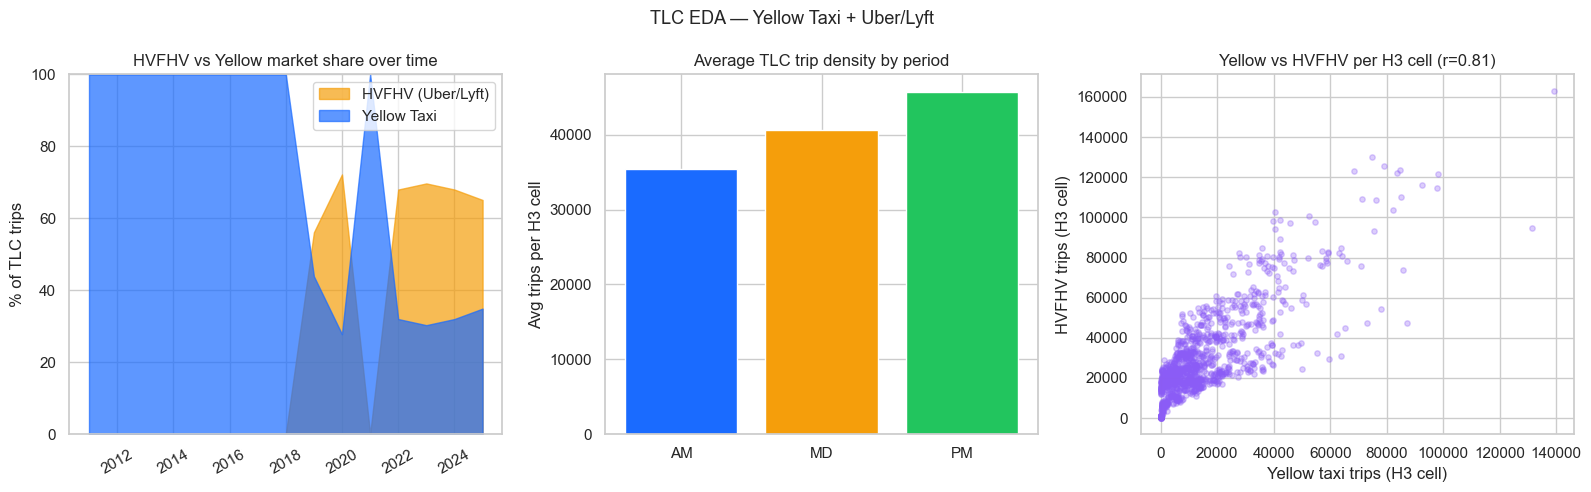

In [64]:
# EDA — TLC demand patterns 

if not tlc_h3_all.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # (a) Yellow vs HVFHV share over time
    breakdown['survey_date'] = pd.to_datetime(breakdown['year'].astype(str) + '-01-01')
    axes[0].fill_between(breakdown['survey_date'], breakdown['hvfhv_pct'],
                         label='HVFHV (Uber/Lyft)', color=ORANGE, alpha=0.7)
    axes[0].fill_between(breakdown['survey_date'], 100 - breakdown['hvfhv_pct'],
                         label='Yellow Taxi', color=BLUE, alpha=0.7, where=breakdown['hvfhv_pct'] < 100)
    axes[0].set_title('HVFHV vs Yellow market share over time')
    axes[0].set_ylabel('% of TLC trips')
    axes[0].set_ylim(0, 100)
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=30)

    # (b) Total trips by period
    period_agg = tlc_h3_all.groupby('period')['tlc_trip_count'].mean()
    axes[1].bar(PERIOD_ORDER, [period_agg.get(p, 0) for p in PERIOD_ORDER],
                color=[PERIOD_COLORS[p] for p in PERIOD_ORDER])
    axes[1].set_title('Average TLC trip density by period')
    axes[1].set_ylabel('Avg trips per H3 cell')

    # (c) HVFHV trips vs yellow trips scatter
    scatter_data = tlc_h3_all[tlc_h3_all['tlc_hvfhv_trips'] > 0]
    axes[2].scatter(scatter_data['tlc_yellow_trips'], scatter_data['tlc_hvfhv_trips'],
                    alpha=0.3, s=15, color=PURPLE)
    axes[2].set_xlabel('Yellow taxi trips (H3 cell)')
    axes[2].set_ylabel('HVFHV trips (H3 cell)')
    axes[2].set_title('Yellow vs HVFHV trips per H3 cell')
    r = scatter_data['tlc_yellow_trips'].corr(scatter_data['tlc_hvfhv_trips'])
    axes[2].set_title(f'Yellow vs HVFHV per H3 cell (r={r:.2f})')

    plt.suptitle('TLC EDA — Yellow Taxi + Uber/Lyft', fontsize=13)
    plt.tight_layout()
    plt.savefig(PLOTS / 'eda_tlc_yellow_hvfhv.png', dpi=120, bbox_inches='tight')
    plt.show()

## 4 · MTA Subway — H3 Aggregation (2020+)

MTA publishes hourly ridership by station from 2020 onward (dataset `5wq4-mkjj`).
We assign each station to an H3 cell using the station lat/lon, then aggregate
to `(h3_cell, period)`.

For survey dates before 2020 there is no MTA data — we will handle those nulls
in the feature engineering step.

In [65]:
# MTA fetch function 

MTA_START_YEAR = 2020

def fetch_mta_h3(survey_date_str):
    """
    Download MTA subway ridership for one date from data.ny.gov.
    Assigns stations to H3 cells using lat/lon, aggregates to (h3_cell, period).
    Returns DataFrame or None if data unavailable.
    """
    year = int(survey_date_str[:4])
    if year < MTA_START_YEAR:
        return None

    cache = RAW / f'mta_h3_{survey_date_str}.csv'
    if cache.exists():
        df = pd.read_csv(cache)
        df['survey_date'] = pd.to_datetime(df['survey_date'])
        return df

    params = {
        '$where': (
            f"transit_timestamp >= '{survey_date_str}T00:00:00' "
            f"AND transit_timestamp < '{survey_date_str}T23:59:59' "
            f"AND borough = 'Manhattan' "
            f"AND transit_mode = 'subway'"
        ),
        '$select': 'transit_timestamp,station_complex,ridership,transfers,latitude,longitude',
        '$limit': 50000,
    }

    try:
        r = requests.get('https://data.ny.gov/resource/5wq4-mkjj.json', params=params, timeout=120)
        r.raise_for_status()
        mta = pd.DataFrame(r.json())
    except Exception as e:
        print(f'    MTA fetch error: {e}')
        return None

    if mta.empty:
        return None

    mta['transit_timestamp'] = pd.to_datetime(mta['transit_timestamp'], errors='coerce')
    mta['ridership']  = pd.to_numeric(mta['ridership'],  errors='coerce')
    mta['transfers']  = pd.to_numeric(mta.get('transfers', pd.Series(dtype=float)), errors='coerce').fillna(0)

    if 'latitude' not in mta.columns:
        return None

    mta['lat'] = pd.to_numeric(mta['latitude'],  errors='coerce')
    mta['lon'] = pd.to_numeric(mta['longitude'], errors='coerce')
    mta = mta.dropna(subset=['lat', 'lon', 'ridership'])
    mta = mta[mta['ridership'] >= 0]

    mta['h3_cell'] = mta.apply(lambda r: h3.latlng_to_cell(r['lat'], r['lon'], H3_RES), axis=1)
    mta['hour'] = mta['transit_timestamp'].dt.hour
    mta['period']  = mta['hour'].apply(hour_to_period)
    mta = mta.dropna(subset=['period'])

    agg = (
        mta.groupby(['h3_cell', 'period'])
        .agg(
            mta_ridership_total = ('ridership',        'sum'),
            mta_ridership_avg = ('ridership',        'mean'),
            mta_station_count = ('station_complex',  'nunique'),
            mta_transfers_total = ('transfers',        'sum'),
        )
        .reset_index()
    )
    agg['mta_load_score'] = norm_score(agg['mta_ridership_total'])
    agg['survey_date'] = survey_date_str

    agg.to_csv(cache, index=False)
    return agg


print('MTA fetch function defined.')

MTA fetch function defined.


In [66]:
# Run MTA fetch for all survey dates 

mta_parts = []

for _, srow in survey_dates.iterrows():
    sd = str(srow['survey_date'])[:10]
    print(f'MTA → {sd} ...', end='  ')
    result = fetch_mta_h3(sd)
    if result is not None:
        mta_parts.append(result)
        print(f'{len(result)} H3-period rows  |  ridership={result["mta_ridership_total"].sum():,.0f}')
    else:
        print('Skipped (before 2020 or download failed)')

if mta_parts:
    mta_h3_all = pd.concat(mta_parts, ignore_index=True)
    mta_h3_all['survey_date'] = pd.to_datetime(mta_h3_all['survey_date'])
    mta_h3_all.to_csv(PROC / 'mta_h3_all_dates.csv', index=False)
    print(f'\nTotal MTA H3 rows: {len(mta_h3_all):,}')
    dqr('MTA H3 — Manhattan (2020+)', mta_h3_all, date_col='survey_date')
    save_dqp(mta_h3_all, 'mta_h3')
    display(dqp(mta_h3_all))
else:
    print('No MTA data loaded.')
    mta_h3_all = pd.DataFrame()

MTA → 2007-05-15 ...  Skipped (before 2020 or download failed)
MTA → 2007-09-15 ...  Skipped (before 2020 or download failed)
MTA → 2008-05-15 ...  Skipped (before 2020 or download failed)
MTA → 2008-09-15 ...  Skipped (before 2020 or download failed)
MTA → 2009-05-15 ...  Skipped (before 2020 or download failed)
MTA → 2009-09-15 ...  Skipped (before 2020 or download failed)
MTA → 2010-05-15 ...  Skipped (before 2020 or download failed)
MTA → 2010-09-15 ...  Skipped (before 2020 or download failed)
MTA → 2011-05-15 ...  Skipped (before 2020 or download failed)
MTA → 2011-09-15 ...  Skipped (before 2020 or download failed)
MTA → 2012-05-15 ...  Skipped (before 2020 or download failed)
MTA → 2012-09-15 ...  Skipped (before 2020 or download failed)
MTA → 2013-05-15 ...  Skipped (before 2020 or download failed)
MTA → 2013-09-15 ...  Skipped (before 2020 or download failed)
MTA → 2014-05-15 ...  Skipped (before 2020 or download failed)
MTA → 2014-09-15 ...  Skipped (before 2020 or download 

,dtype,null_count,null_pct,unique,min,mean,median,max
column,,,,,,,,
h3_cell,object,0,0.000,59,NaN,NaN,NaN,NaN
period,object,0,0.000,3,NaN,NaN,NaN,NaN
mta_ridership_total,float64,0,0.000,350,287.000,8427.059,4385.500,89945.000
mta_ridership_avg,float64,0,0.000,353,10.033,122.245,74.859,1183.424
mta_station_count,int64,0,0.000,6,1.000,2.051,2.000,7.000
mta_transfers_total,float64,0,0.000,228,0.000,214.932,116.500,3794.000
mta_load_score,float64,0,0.000,314,39.020,49.304,44.530,100.000
survey_date,datetime64[ns],0,0.000,2,NaN,NaN,NaN,NaN


## Weather — Period Aggregation (all years)

We use the **Open-Meteo Historical Archive API** — completely free, no API key needed,
covers data going back to 1940. Weather is Manhattan-wide (one reading per time period),
so there is no H3 spatial join here — every pedestrian location gets the same weather
for a given date × period.

In [67]:
# Weather fetch function 

def wmo_to_category(code):
    """Convert WMO weather code to a human-readable category string."""
    if pd.isna(code): return 'unknown'
    c = int(code)
    if c == 0:             return 'clear'
    if c in range(1, 4):   return 'partly_cloudy'
    if c in range(51, 68): return 'rain'
    if c in range(71, 78): return 'snow'
    if c in range(80, 86): return 'rain_shower'
    if c in range(95,100): return 'thunderstorm'
    return 'other'


def fetch_weather_periods(survey_date_str):
    """
    Fetch hourly weather for Manhattan on survey_date from Open-Meteo archive.
    Aggregates to the three time periods (AM, MD, PM).
    Returns a 3-row dataframe, or None on failure.
    """
    cache = RAW / f'weather_{survey_date_str}.csv'
    if cache.exists():
        df = pd.read_csv(cache)
        df['survey_date'] = pd.to_datetime(df['survey_date'])
        return df

    params = {
        'latitude':  40.7789,
        'longitude': -73.9692,
        'start_date': survey_date_str,
        'end_date':   survey_date_str,
        'hourly': ('temperature_2m,apparent_temperature,precipitation,'
                   'windspeed_10m,weathercode,relative_humidity_2m'),
        'timezone':          'America/New_York',
        'temperature_unit':  'fahrenheit',
        'windspeed_unit':    'mph',
        'precipitation_unit':'inch',
    }

    try:
        r = requests.get('https://archive-api.open-meteo.com/v1/archive', params=params, timeout=60)
        r.raise_for_status()
        wth = pd.DataFrame(r.json()['hourly'])
    except Exception as e:
        print(f'    Weather error: {e}')
        return None

    wth['time']   = pd.to_datetime(wth['time'], errors='coerce')
    wth['hour']   = wth['time'].dt.hour
    wth['period'] = wth['hour'].apply(hour_to_period)
    wth = wth.dropna(subset=['period'])

    if 'weathercode' in wth.columns:
        wth['weather_cat'] = wth['weathercode'].apply(wmo_to_category)
        wth['is_rain'] = wth['weather_cat'].isin(['rain', 'rain_shower']).astype(int)
        wth['is_snow'] = (wth['weather_cat'] == 'snow').astype(int)
        wth['is_bad_weather'] = ((wth['is_rain'] + wth['is_snow']) > 0).astype(int)

    # Aggregate each numeric field to period level
    agg_cols = {
        'avg_temperature_f':   ('temperature_2m',       'mean'),
        'avg_apparent_temp_f': ('apparent_temperature', 'mean'),
        'total_precip_in':     ('precipitation',        'sum'),
        'avg_windspeed_mph':   ('windspeed_10m',        'mean'),
        'avg_humidity_pct':    ('relative_humidity_2m', 'mean'),
    }
    agg_cols = {k: v for k, v in agg_cols.items() if v[0] in wth.columns}

    weather = wth.groupby('period').agg(**agg_cols).reset_index()

    if 'is_bad_weather' in wth.columns:
        bad = wth.groupby('period')['is_bad_weather'].max().reset_index()
        weather = weather.merge(bad, on='period')

    weather['survey_date'] = survey_date_str
    weather.to_csv(cache, index=False)
    return weather


print('Weather fetch function defined.')

Weather fetch function defined.


In [68]:
#  Run weather fetch for all survey dates 

weather_parts = []

for _, srow in survey_dates.iterrows():
    sd = str(srow['survey_date'])[:10]
    print(f'Weather → {sd} ...', end='  ')
    result = fetch_weather_periods(sd)
    if result is not None:
        weather_parts.append(result)
        avg_temp = result['avg_temperature_f'].mean() if 'avg_temperature_f' in result else 'N/A'
        print(f'{len(result)} period rows  |  avg temp={avg_temp:.1f}°F')
    else:
        print('Failed')

if weather_parts:
    weather_all = pd.concat(weather_parts, ignore_index=True)
    weather_all['survey_date'] = pd.to_datetime(weather_all['survey_date'])
    weather_all.to_csv(PROC / 'weather_all_dates.csv', index=False)
    print(f'\nTotal weather rows: {len(weather_all)}')
    dqr('Weather — All Survey Dates', weather_all, date_col='survey_date')
    save_dqp(weather_all, 'weather')
    display(dqp(weather_all))
else:
    weather_all = pd.DataFrame()

Weather → 2007-05-15 ...  3 period rows  |  avg temp=70.7°F
Weather → 2007-09-15 ...  3 period rows  |  avg temp=65.5°F
Weather → 2008-05-15 ...  3 period rows  |  avg temp=61.4°F
Weather → 2008-09-15 ...  3 period rows  |  avg temp=76.5°F
Weather → 2009-05-15 ...  3 period rows  |  avg temp=66.9°F
Weather → 2009-09-15 ...  3 period rows  |  avg temp=70.8°F
Weather → 2010-05-15 ...  3 period rows  |  avg temp=65.5°F
Weather → 2010-09-15 ...  3 period rows  |  avg temp=65.2°F
Weather → 2011-05-15 ...  3 period rows  |  avg temp=63.1°F
Weather → 2011-09-15 ...  3 period rows  |  avg temp=68.9°F
Weather → 2012-05-15 ...  3 period rows  |  avg temp=62.2°F
Weather → 2012-09-15 ...  3 period rows  |  avg temp=67.5°F
Weather → 2013-05-15 ...  3 period rows  |  avg temp=60.7°F
Weather → 2013-09-15 ...  3 period rows  |  avg temp=63.1°F
Weather → 2014-05-15 ...  3 period rows  |  avg temp=65.1°F
Weather → 2014-09-15 ...  3 period rows  |  avg temp=62.9°F
Weather → 2015-05-15 ...  3 period rows 

,dtype,null_count,null_pct,unique,min,mean,median,max
column,,,,,,,,
period,object,0,0.000,3,NaN,NaN,NaN,NaN
avg_temperature_f,float64,0,0.000,107,44.100,65.573,66.050,83.000
avg_apparent_temp_f,float64,0,0.000,104,37.300,63.587,64.150,84.367
total_precip_in,float64,0,0.000,13,0.000,0.008,0.000,0.181
avg_windspeed_mph,float64,0,0.000,96,1.867,8.037,7.550,20.600
avg_humidity_pct,float64,0,0.000,87,23.333,63.880,63.000,98.667
is_bad_weather,int64,0,0.000,2,0.000,0.213,0.000,1.000
survey_date,datetime64[ns],0,0.000,36,NaN,NaN,NaN,NaN


## 6 · Master Merge — H3-Aware Spatial Join

Now we join everything together. The key insight is that TLC and MTA features are
**location-specific** thanks to the H3 join — Times Square (h3_cell=A) gets different
taxi/subway numbers than East Harlem (h3_cell=B) on the same date.

In [69]:
# ── 6.1  Run the spatial merge ───────────────────────────────────────────

# Start with pedestrian rows that have an H3 cell assigned
ped_with_h3 = ped_long.dropna(subset=['h3_cell']).copy()
print(f'Pedestrian rows with H3 cell: {len(ped_with_h3):,}')
print(f'Rows dropped (no geocode):    {len(ped_long) - len(ped_with_h3):,}')

master = ped_with_h3.copy()

# Join TLC (location-specific via H3)
if not tlc_h3_all.empty:
    tlc_h3_all['survey_date'] = pd.to_datetime(tlc_h3_all['survey_date'])
    master = master.merge(tlc_h3_all.drop(columns=['year'], errors='ignore'),
                          on=['h3_cell', 'survey_date', 'period'], how='left')
    print(f'After TLC join:     {master.shape}')

# Join MTA (location-specific via H3)
if not mta_h3_all.empty:
    mta_h3_all['survey_date'] = pd.to_datetime(mta_h3_all['survey_date'])
    master = master.merge(mta_h3_all,
                          on=['h3_cell', 'survey_date', 'period'], how='left')
    print(f'After MTA join:     {master.shape}')

# Join weather (city-wide — same for all locations on a given date × period)
if not weather_all.empty:
    weather_all['survey_date'] = pd.to_datetime(weather_all['survey_date'])
    master = master.merge(weather_all,
                          on=['survey_date', 'period'], how='left')
    print(f'After weather join: {master.shape}')

print(f'\nMaster dataset: {master.shape[0]:,} rows × {master.shape[1]} columns')
print(f'Survey dates: {master["survey_date"].nunique()}')
print(f'Locations:    {master["location_id"].nunique()}')
print(f'Periods:      {master["period"].nunique()}')

Pedestrian rows with H3 cell: 3,826
Rows dropped (no geocode):    0
After TLC join:     (3826, 25)
After MTA join:     (3826, 30)
After weather join: (3826, 36)

Master dataset: 3,826 rows × 36 columns
Survey dates: 36
Locations:    36
Periods:      3


In [70]:
# Validate: TLC features vary by location 
# This is a sanity check. The whole point of the H3 join is that Times Square
# gets a different taxi count than a quiet side street on the same date.
# If all values are the same, something went wrong with the join keys.

if 'tlc_trip_count' in master.columns:
    sample_date = master.loc[master['tlc_trip_count'].notna(), 'survey_date'].max()
    sample = master[
        (master['survey_date'] == sample_date) & (master['period'] == 'AM')
    ][['street', 'h3_cell', 'tlc_trip_count', 'tlc_hvfhv_trips', 'pedestrians']].sort_values(
        'tlc_trip_count', ascending=False
    )

    print(f'TLC counts by location on {str(sample_date)[:10]} AM:')
    display(sample.head(10))

    n_distinct = sample['tlc_trip_count'].nunique()
    if n_distinct > 1:
        print(f'\n PASS: {n_distinct} distinct TLC values across {len(sample)} locations')
        print('  H3-based spatial join is working correctly.')
    else:
        print('\n WARNING: All locations have the same TLC value.')
        print('  Check that zone_df h3_cell values match loc_df h3_cell values.')
else:
    print('TLC data not available for validation.')

TLC counts by location on 2025-10-15 AM:


,street,h3_cell,tlc_trip_count,tlc_hvfhv_trips,pedestrians
105,Broad Street,882a107281fffff,120395.000,84530.000,2846.000
213,Broadway,882a107281fffff,120395.000,84530.000,3065.000
2660,West 47th Street,882a100d67fffff,97211.000,63385.000,2823.000
2557,West 40th Street,882a100d67fffff,97211.000,63385.000,3149.000
1068,Eighth Avenue,882a10725bfffff,87875.000,52149.000,6895.000
1280,Forsyth Street,882a1072c3fffff,76994.000,46550.000,946.000
3505,Seventh Avenue,882a100d65fffff,67861.000,54654.000,3117.000
3613,Broadway,882a100d65fffff,67861.000,54654.000,1022.000
3718,Eighth Avenue,882a100d65fffff,67861.000,54654.000,3459.000
3401,Sixth Avenue,882a100d65fffff,67861.000,54654.000,2999.000



 PASS: 14 distinct TLC values across 36 locations
  H3-based spatial join is working correctly.


## 7 · Feature Engineering, Cleaning & DQR/DQP

Here we build the features that the ML models will actually use:
- **Log transform** of the target (pedestrian counts are very right-skewed)
- **Cyclic encodings** for month and period (so the model knows December is close to January)
- **Period dummies** (is it AM? is it PM?)
- **Lag features** — pedestrian count at the same location × period in previous surveys
- **Location baseline** — each location's median pedestrian count per period
- **Missing-value flags** for TLC/MTA features (they are null for pre-2009/pre-2020 dates)

In [71]:
# Feature engineering 

final = master.copy()

# Log transform of target — helps with heavily skewed distributions
final['log_pedestrians'] = np.log1p(final['pedestrians'])

# Cyclic month encoding (month 12 and month 1 should be close to each other)
final['month_sin'] = np.sin(2 * np.pi * final['month'] / 12)
final['month_cos'] = np.cos(2 * np.pi * final['month'] / 12)

# Numeric period (for cyclic encoding)
period_num = {'AM': 0, 'MD': 1, 'PM': 2}
final['period_num'] = final['period'].map(period_num)
final['period_sin'] = np.sin(2 * np.pi * final['period_num'] / 3)
final['period_cos'] = np.cos(2 * np.pi * final['period_num'] / 3)

# Period one-hot dummies (easy for tree models to split on)
final['is_AM'] = (final['period'] == 'AM').astype(int)
final['is_MD'] = (final['period'] == 'MD').astype(int)
final['is_PM'] = (final['period'] == 'PM').astype(int)

# Season dummies
final['is_spring'] = final['season'].isin(['May', 'June']).astype(int)
final['is_fall']   = final['season'].isin(['Sept', 'Oct']).astype(int)

# Lag features — pedestrian count at the same location × period in previous surveys
# This captures trends like "this location was growing year over year"
final = final.sort_values(['location_id', 'period', 'survey_date'])
final['ped_lag_1survey'] = final.groupby(['location_id', 'period'])['pedestrians'].shift(1)
final['ped_lag_2survey'] = final.groupby(['location_id', 'period'])['pedestrians'].shift(2)
final['ped_yoy_change']  = final['pedestrians'] - final['ped_lag_1survey']

# Location-level baseline — each corridor's typical crowd at each time of day
# This lets the model know: "Times Square is always busy; this survey was above/below normal"
loc_baseline = (
    final.groupby(['location_id', 'period'])['pedestrians']
    .median()
    .reset_index()
    .rename(columns={'pedestrians': 'loc_period_baseline'})
)
final = final.merge(loc_baseline, on=['location_id', 'period'], how='left')
final['ped_deviation'] = final['pedestrians'] - final['loc_period_baseline']

print(f'Final shape after feature engineering: {final.shape}')
print(f'Null cells: {final.isnull().sum().sum():,}')

Final shape after feature engineering: (3826, 52)
Null cells: 32,126


In [72]:
# Handle missing values 
# TLC/MTA are null for dates before those APIs existed.
# We fill with 0 and add a binary "was this actually null?" flag column.
# This way the model can learn: "when TLC data is missing, it's an old survey"

# TLC columns
tlc_cols = [c for c in final.columns if c.startswith('tlc_') and c != 'tlc_load_score']
for col in tlc_cols:
    final[f'{col}_missing'] = final[col].isna().astype(int)
    final[col] = final[col].fillna(0)

# MTA columns
mta_cols = [c for c in final.columns if c.startswith('mta_') and c != 'mta_load_score']
for col in mta_cols:
    final[f'{col}_missing'] = final[col].isna().astype(int)
    final[col] = final[col].fillna(0)

# Fill load scores with 0 too
for col in ['tlc_load_score', 'mta_load_score']:
    if col in final.columns:
        final[col] = final[col].fillna(0)

# Weather — fill nulls with the column median (robust to outliers)
weather_cols = [c for c in final.columns if c in [
    'avg_temperature_f', 'avg_apparent_temp_f', 'total_precip_in',
    'avg_windspeed_mph', 'avg_humidity_pct', 'is_bad_weather'
]]
for col in weather_cols:
    median_val = final[col].median()
    final[col] = final[col].fillna(median_val)

remaining_nulls = final.isnull().sum().sum()
print(f'Null cells after cleaning: {remaining_nulls:,}')
if remaining_nulls > 0:
    null_cols = final.columns[final.isnull().any()].tolist()
    print(f'Columns still with nulls: {null_cols}')
    print('  (lag features will be null for the first 1-2 observations per location — expected)')

Null cells after cleaning: 432
Columns still with nulls: ['ped_lag_1survey', 'ped_lag_2survey', 'ped_yoy_change']
  (lag features will be null for the first 1-2 observations per location — expected)


In [73]:
# Feature selection — what to include in the final dataset 

INDEX_COLS = [
    'location_id', 'street', 'from_street', 'to_street', 'borough',
    'lat', 'lon', 'h3_cell', 'description', 'survey_date', 'year',
    'month', 'season', 'period'
]
TARGET_COLS = ['pedestrians', 'log_pedestrians', 'ped_score']

# Everything else that is not an index or target is a feature
FEATURE_COLS = [
    c for c in final.columns
    if c not in INDEX_COLS + TARGET_COLS and not c.startswith('_')
]

print(f'Index columns:   {len(INDEX_COLS)}')
print(f'Target columns:  {len(TARGET_COLS)}')
print(f'Feature columns: {len(FEATURE_COLS)}')
print()
print('Features by group:')
feature_groups = {
    'tlc_':       'TLC demand (Yellow + HVFHV, location-specific via H3)',
    'mta_':       'MTA ridership (location-specific via H3)',
    'avg_':       'Weather — continuous',
    'total_prec': 'Weather — precipitation',
    'is_bad':     'Weather — rain/snow flag',
    'is_AM':      'Period dummy',
    'is_MD':      'Period dummy',
    'is_PM':      'Period dummy',
    'is_spring':  'Season dummy',
    'is_fall':    'Season dummy',
    'ped_lag':    'Lag features (previous survey)',
    'ped_dev':    'Deviation from location baseline',
    'ped_yoy':    'Year-over-year change',
    'month_':     'Cyclic month encoding',
    'period_':    'Cyclic period encoding',
    'loc_period': 'Location × period baseline',
}
for prefix, label in feature_groups.items():
    cols = [c for c in FEATURE_COLS if c.startswith(prefix)]
    if cols:
        print(f'  {label}: {cols}')

# Correlation of each feature with the pedestrian target
num_features = [c for c in FEATURE_COLS if pd.api.types.is_numeric_dtype(final[c])]
corrs = final[num_features + ['pedestrians']].corr()['pedestrians'].drop('pedestrians')
corrs = corrs.sort_values(key=abs, ascending=False)

feature_manifest = pd.DataFrame({
    'feature':                corrs.index,
    'corr_with_pedestrians':  corrs.values.round(3),
    'null_pct':               [round(final[c].isna().mean() * 100, 2) for c in corrs.index],
    'dtype':                  [str(final[c].dtype) for c in corrs.index],
})

print()
print('Top 10 features by |correlation| with pedestrian count:')
display(feature_manifest.head(10))

Index columns:   14
Target columns:  3
Feature columns: 46

Features by group:
  TLC demand (Yellow + HVFHV, location-specific via H3): ['tlc_trip_count', 'tlc_avg_fare', 'tlc_avg_dist_mi', 'tlc_yellow_trips', 'tlc_hvfhv_trips', 'tlc_yellow_share', 'tlc_hvfhv_share', 'tlc_load_score', 'tlc_trip_count_missing', 'tlc_avg_fare_missing', 'tlc_avg_dist_mi_missing', 'tlc_yellow_trips_missing', 'tlc_hvfhv_trips_missing', 'tlc_yellow_share_missing', 'tlc_hvfhv_share_missing']
  MTA ridership (location-specific via H3): ['mta_ridership_total', 'mta_ridership_avg', 'mta_station_count', 'mta_transfers_total', 'mta_load_score', 'mta_ridership_total_missing', 'mta_ridership_avg_missing', 'mta_station_count_missing', 'mta_transfers_total_missing']
  Weather — continuous: ['avg_temperature_f', 'avg_apparent_temp_f', 'avg_windspeed_mph', 'avg_humidity_pct']
  Weather — precipitation: ['total_precip_in']
  Weather — rain/snow flag: ['is_bad_weather']
  Period dummy: ['is_AM']
  Period dummy: ['is_MD']


,feature,corr_with_pedestrians,null_pct,dtype
0,loc_period_baseline,0.888,0.000,float64
1,ped_lag_1survey,0.881,2.820,float64
2,ped_lag_2survey,0.857,5.650,float64
3,is_PM,0.497,0.000,int64
4,period_num,0.471,0.000,int64
5,period_sin,-0.390,0.000,float64
6,ped_deviation,0.371,0.000,float64
7,period_cos,-0.319,0.000,float64
8,is_AM,-0.319,0.000,int64
9,avg_temperature_f,0.252,0.000,float64


In [74]:
#  Full DQR + DQP on final dataset 

dqr('Zentra Master — Final (pre-export)', final, date_col='survey_date')
print()
dqp_final = dqp(final)
display(dqp_final)

dqp_final.to_csv(PROC / 'dqp_master_final.csv')
print(f'DQP saved → {PROC / "dqp_master_final.csv"}')

DATA QUALITY REPORT — Zentra Master — Final (pre-export)    
Rows:      3,826
Columns:         63
Null cells: 432 (0.18%)                                       
Date range: 2007-05-15  →  2025-10-15



,dtype,null_count,null_pct,unique,min,mean,median,max
column,,,,,,,,
location_id,int64,0,0.000,36,35.000,52.443,52.000,70.000
street,object,0,0.000,28,NaN,NaN,NaN,NaN
from_street,object,0,0.000,24,NaN,NaN,NaN,NaN
to_street,object,0,0.000,24,NaN,NaN,NaN,NaN
borough,object,0,0.000,1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
tlc_hvfhv_share_missing,int64,0,0.000,2,0.000,0.440,0.000,1.000
mta_ridership_total_missing,int64,0,0.000,2,0.000,0.953,1.000,1.000
mta_ridership_avg_missing,int64,0,0.000,2,0.000,0.953,1.000,1.000


DQP saved → ..\data\processed\dqp_master_final.csv


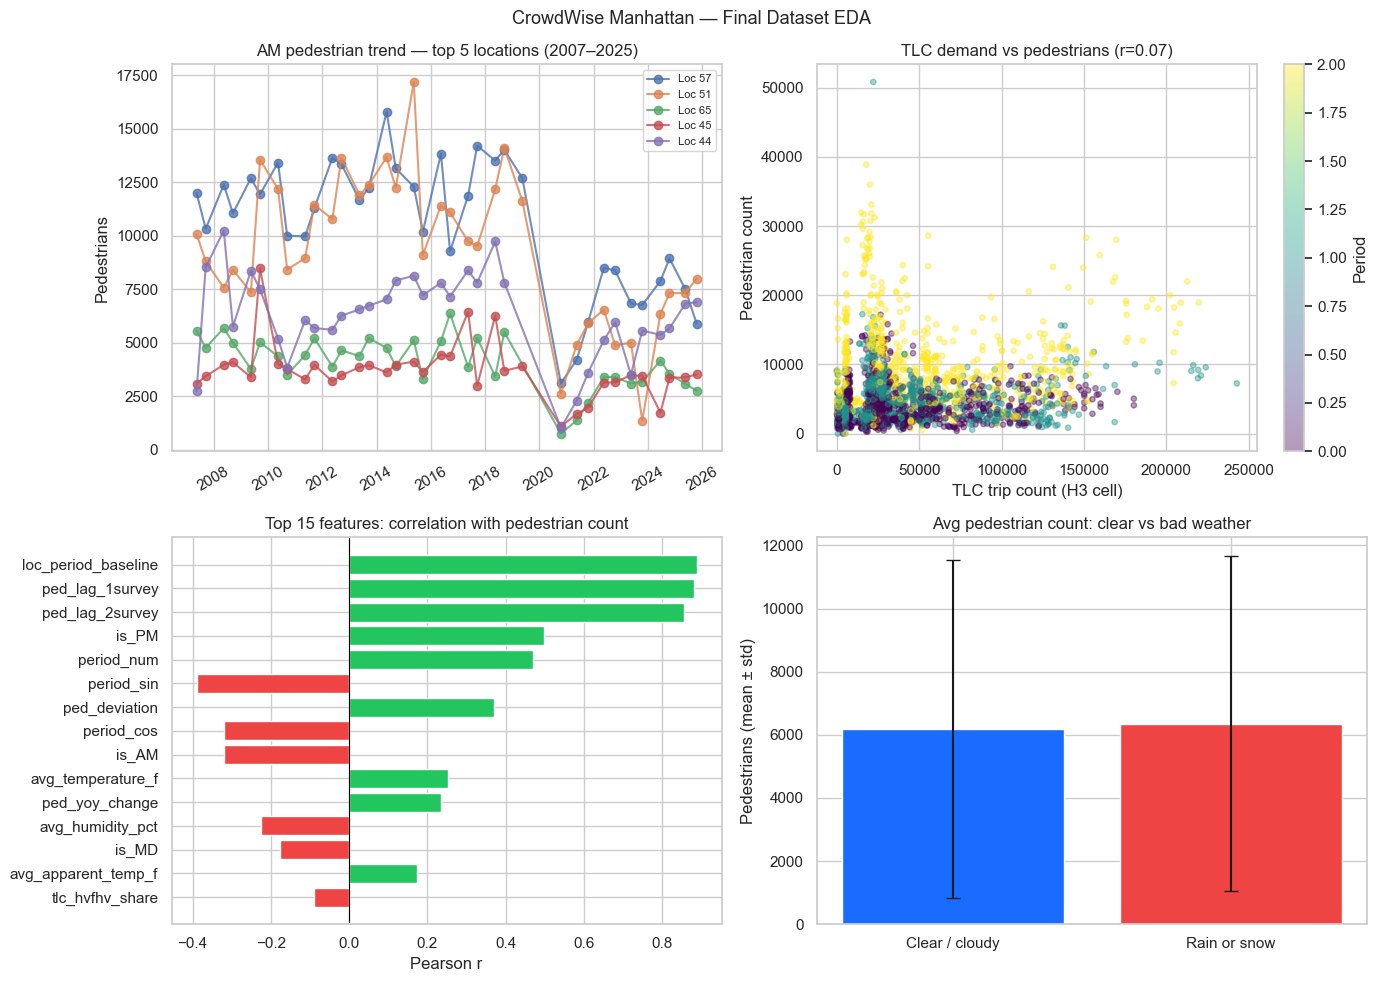

Plot saved → data/plots/eda_final_dataset.png


In [75]:
# =EDA plots on the final dataset 

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) AM trend — top 5 busiest locations
top5 = final.groupby('location_id')['pedestrians'].mean().nlargest(5).index
for loc in top5:
    sub = final[(final['location_id'] == loc) & (final['period'] == 'AM')].sort_values('survey_date')
    axes[0, 0].plot(sub['survey_date'], sub['pedestrians'], 'o-', label=f'Loc {loc}', alpha=0.8)
axes[0, 0].set_title('AM pedestrian trend — top 5 locations (2007–2025)')
axes[0, 0].legend(fontsize=8)
axes[0, 0].tick_params(axis='x', rotation=30)
axes[0, 0].set_ylabel('Pedestrians')

# (2) TLC demand vs pedestrians (shows the H3 join is working)
if 'tlc_trip_count' in final.columns and final['tlc_trip_count'].sum() > 0:
    sub = final[final['tlc_trip_count'] > 0]
    c_map = {'AM': 0, 'MD': 1, 'PM': 2}
    sc = axes[0, 1].scatter(sub['tlc_trip_count'], sub['pedestrians'],
                             c=[c_map[p] for p in sub['period']],
                             cmap='viridis', alpha=0.4, s=15)
    r = sub['tlc_trip_count'].corr(sub['pedestrians'])
    axes[0, 1].set_title(f'TLC demand vs pedestrians (r={r:.2f})')
    axes[0, 1].set_xlabel('TLC trip count (H3 cell)')
    axes[0, 1].set_ylabel('Pedestrian count')
    plt.colorbar(sc, ax=axes[0, 1], label='Period')
else:
    axes[0, 1].text(0.5, 0.5, 'TLC data not available', ha='center', va='center')

# (3) Top 15 features by correlation with pedestrians
top15 = feature_manifest.head(15)
colors = [GREEN if v > 0 else RED for v in top15['corr_with_pedestrians']]
axes[1, 0].barh(top15['feature'][::-1], top15['corr_with_pedestrians'][::-1], color=colors[::-1])
axes[1, 0].axvline(0, color='black', linewidth=0.8)
axes[1, 0].set_title('Top 15 features: correlation with pedestrian count')
axes[1, 0].set_xlabel('Pearson r')

# (4) Weather effect on pedestrian counts
if 'is_bad_weather' in final.columns:
    wg = final.groupby('is_bad_weather')['pedestrians'].agg(['mean', 'std'])
    labels = ['Clear / cloudy', 'Rain or snow']
    axes[1, 1].bar(labels, wg['mean'].values, yerr=wg['std'].values,
                   color=[BLUE, RED], capsize=5)
    axes[1, 1].set_title('Avg pedestrian count: clear vs bad weather')
    axes[1, 1].set_ylabel('Pedestrians (mean ± std)')
else:
    axes[1, 1].text(0.5, 0.5, 'Weather data not available', ha='center', va='center')

plt.suptitle('CrowdWise Manhattan — Final Dataset EDA', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS / 'eda_final_dataset.png', dpi=120, bbox_inches='tight')
plt.show()

print('Plot saved → data/plots/eda_final_dataset.png')

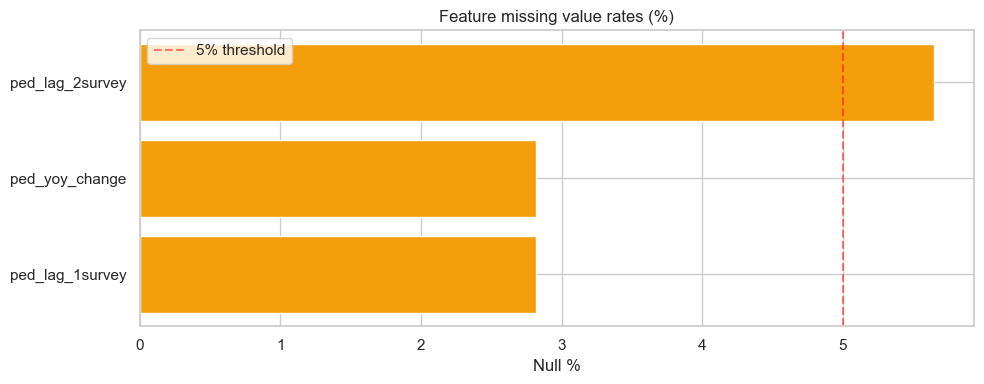

3 features have missing values


In [76]:
# Feature null % chart 
# Shows which features have missing values and how many

null_features = feature_manifest[feature_manifest['null_pct'] > 0].sort_values('null_pct')

if len(null_features) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(null_features) * 0.35)))
    ax.barh(null_features['feature'], null_features['null_pct'], color=ORANGE)
    ax.set_title('Feature missing value rates (%)')
    ax.set_xlabel('Null %')
    ax.axvline(5, color='red', linestyle='--', alpha=0.5, label='5% threshold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(PLOTS / 'feature_null_rates.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'{len(null_features)} features have missing values')
else:
    print('All features are 100% complete!')

## 8 · Export Final CSVs

Three output files:
1. **`zentra_multidate_h3.csv`** — the full feature table, primary input for LightGBM
2. **`zentra_prophet_ready.csv`** — `ds` / `y` format for Prophet time series modelling
3. **`feature_manifest_h3.csv`** — feature metadata (correlations, null %, dtype)

In [79]:
# Save all final CSVs 

ALL_COLS = [c for c in INDEX_COLS + TARGET_COLS + FEATURE_COLS if c in final.columns]
final_export = final[ALL_COLS].copy()

# (A) Main ML dataset — LightGBM input
out_master = MASTER / 'zentra_multidate_h3.csv'
final_export.to_csv(out_master, index=False)

# (B) Prophet-ready (ds = timestamp, y = target)
prophet_df = final_export[[
    'location_id', 'period', 'survey_date', 'pedestrians', 'log_pedestrians'
] + [c for c in FEATURE_COLS if c in final_export.columns]].copy()
prophet_df = prophet_df.rename(columns={'survey_date': 'ds', 'pedestrians': 'y'})
out_prophet = MASTER / 'zentra_prophet_ready.csv'
prophet_df.to_csv(out_prophet, index=False)

# (C) Feature manifest
out_manifest = MASTER / 'feature_manifest_h3.csv'
feature_manifest.to_csv(out_manifest, index=False)

# (D) DQP on final export
dqp(final_export).to_csv(MASTER / 'dqp_final_export.csv')

print('=' * 60)
print('OUTPUTS')
print('=' * 60)
print(f' {out_master}')
print(f' Shape: {final_export.shape}  ← LightGBM input')
print()
print(f' {out_prophet}')
print(f' Shape: {prophet_df.shape}  ← Prophet input (ds / y format)')
print()
print(f' {out_manifest}')
print(f' {len(feature_manifest)} features with correlation + null % info')
print()
dqr('Zentra Master — Final Export', final_export, date_col='survey_date')

OUTPUTS
 ..\data\master\zentra_multidate_h3.csv
 Shape: (3826, 63)  ← LightGBM input

 ..\data\master\zentra_prophet_ready.csv
 Shape: (3826, 51)  ← Prophet input (ds / y format)

 ..\data\master\feature_manifest_h3.csv
 46 features with correlation + null % info

DATA QUALITY REPORT — Zentra Master — Final Export          
Rows:      3,826
Columns:         63
Null cells: 432 (0.18%)                                       
Date range: 2007-05-15  →  2025-10-15


In [80]:
# Final sanity check 
# Print a clear summary of what got built and flag any concerns.

issues = []

# Check coverage
tlc_coverage = final_export['tlc_trip_count'].notna().mean() * 100 if 'tlc_trip_count' in final_export.columns else 0
mta_coverage = final_export['mta_ridership_total'].notna().mean() * 100 if 'mta_ridership_total' in final_export.columns else 0

print('PIPELINE SUMMARY')
print('═' * 50)
print(f'  Rows in final export:  {len(final_export):,}')
print(f'  Feature count:         {len(FEATURE_COLS)}')
print(f'  Survey dates:          {final_export["survey_date"].nunique()}  ({final_export["survey_date"].min().year}–{final_export["survey_date"].max().year})')
print(f'  Locations:             {final_export["location_id"].nunique()}')
print()
print('DATA SOURCE COVERAGE')
print(f'  TLC (Yellow+HVFHV):  {tlc_coverage:.1f}% of rows (null = pre-2009 surveys)')
print(f'  MTA ridership:       {mta_coverage:.1f}% of rows (null = pre-2020 surveys)')
print(f'  Weather:             {"100.0" if "avg_temperature_f" in final_export.columns and final_export["avg_temperature_f"].notna().all() else "partial"}% of rows')
print()

if 'tlc_hvfhv_trips' in final_export.columns:
    total_yellow = final_export['tlc_yellow_trips'].sum() if 'tlc_yellow_trips' in final_export.columns else 0
    total_hvfhv  = final_export['tlc_hvfhv_trips'].sum()  if 'tlc_hvfhv_trips' in final_export.columns else 0
    if total_yellow + total_hvfhv > 0:
        hvfhv_share = total_hvfhv / (total_yellow + total_hvfhv) * 100
        print(f'TLC COMPOSITION')
        print(f'  Yellow taxi trips:   {total_yellow:,.0f}  ({100-hvfhv_share:.1f}%)')
        print(f'  HVFHV trips:         {total_hvfhv:,.0f}  ({hvfhv_share:.1f}%)')

print()
if not issues:
    print('No issues found. Dataset is ready for modelling!')
else:
    for issue in issues:
        print(f'  WARNING: {issue}')

PIPELINE SUMMARY
══════════════════════════════════════════════════
  Rows in final export:  3,826
  Feature count:         46
  Survey dates:          36  (2007–2025)
  Locations:             36

DATA SOURCE COVERAGE
  TLC (Yellow+HVFHV):  100.0% of rows (null = pre-2009 surveys)
  MTA ridership:       100.0% of rows (null = pre-2020 surveys)
  Weather:             100.0% of rows

TLC COMPOSITION
  Yellow taxi trips:   75,547,666  (71.9%)
  HVFHV trips:         29,462,587  (28.1%)

No issues found. Dataset is ready for modelling!


## 9 · Summary

### What this notebook built

| File | Description |
|------|-------------|
| `data/raw/yellow_YYYY_MM.csv` | Raw Yellow taxi trips per survey month (cached) |
| `data/raw/hvfhv_YYYY_MM.csv` | Raw Uber/Lyft trips per survey month (cached) |
| `data/raw/tlc_h3_combined_DATE.csv` | Combined TLC aggregated to H3 (cached) |
| `data/raw/mta_h3_DATE.csv` | MTA ridership aggregated to H3 (cached) |
| `data/raw/weather_DATE.csv` | Open-Meteo period-level weather (cached) |
| `data/processed/location_geocoded.csv` | 36 corridors with lat/lon + H3 cells |
| `data/processed/tlc_zone_h3_lookup.csv` | TLC zone → H3 centroid mapping |
| `data/processed/pedestrian_long_h3.csv` | Long-format pedestrian counts + H3 |
| `data/processed/tlc_h3_all_dates.csv` | All TLC aggregates (Yellow + HVFHV) |
| `data/processed/mta_h3_all_dates.csv` | All MTA aggregates |
| `data/processed/weather_all_dates.csv` | All weather aggregates |
| `data/processed/dqp_*.csv` | DQP tables per source |
| **`data/master/crowdwise_multidate_h3.csv`** | **LightGBM primary input** |
| **`data/master/crowdwise_prophet_ready.csv`** | **Prophet time-series input (ds/y)** |
| `data/master/feature_manifest_h3.csv` | Feature metadata + correlations |

### Key design decisions

| What | Why |
|------|-----|
| **Yellow Taxi + HVFHV** | Uber/Lyft now dominates Manhattan — yellow-only would miss 60–70% of rideshare demand post-2020 |
| **H3 hex join** | Links TLC/MTA demand to pedestrian locations spatially — Times Square ≠ East Harlem |
| **Missing-value flags** | Pre-2009 (no TLC) and pre-2020 (no MTA) are structurally missing, not random — the flag lets models learn this |
| **Lag features** | Captures temporal trends at each corridor × period without needing Prophet |
| **All survey dates** | ~18 dates from 2007–2025 give the model long-run patterns (COVID dip, post-COVID recovery, etc.) |

### Next steps
- Load `Zentra_multidate_h3.csv` into your LightGBM training notebook
- Load `Zentra_prophet_ready.csv` for per-location time-series forecasting
- Use `feature_manifest_h3.csv` to guide feature selection / importance analysis